In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
plt.rc('font',family='Malgun Gothic' )
!pip install koreanize-matplotlib
from IPython.display import display
import koreanize_matplotlib
import seaborn as sns


In [2]:
origin_train=pd.read_csv("train.csv")
origin_test=pd.read_csv("test.csv")
data_train=origin_train.copy()
data_test=origin_test.copy()


In [3]:
data_train

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,NaN,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,NaN,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,31/10/2018,1507,19,8.4,53,NaN,2000,-0.6,0.0,0.0,0.0,Autumn,No Holiday,Yes
8036,31/10/2018,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,NaN,No Holiday,Yes
8037,31/10/2018,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
8038,31/10/2018,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [4]:
data_test

,Date,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/11/2018,0,5.7,62,2.3,1909,-1.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
1,01/11/2018,1,5.1,65,1.6,1932,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
2,01/11/2018,2,4.4,64,NaN,2000,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
3,01/11/2018,3,4.2,65,0.7,1962,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
4,01/11/2018,4,3.6,70,0.8,1934,-1.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,30/11/2018,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,NaN,No Holiday,Yes
716,30/11/2018,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
717,30/11/2018,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
718,30/11/2018,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


# Train Data EDA

In [5]:
data_train.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(째C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(째C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='str')

In [6]:
# 열 이름 변경 (인코딩 중 한글 깨진 것으로 판단)
data_train = data_train.rename(columns={'Temperature(째C)':'Temperature(C)','Dew point temperature(째C)':'Dew point temperature(C)'})

In [7]:
data_train.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='str')

In [8]:
print(data_train.shape)
data_train.isnull().sum()

(8040, 14)


Date                          0
Rented Bike Count             0
Hour                          0
Temperature(C)              800
Humidity(%)                   0
Wind speed (m/s)            802
Visibility (10m)              0
Dew point temperature(C)      0
Solar Radiation (MJ/m2)       0
Rainfall(mm)                  0
Snowfall (cm)                 0
Seasons                     802
Holiday                       0
Functioning Day               0
dtype: int64

Temperature(C), Wind speed (m/s), Seasons 데이터에 결측치 다수 포진된 것으로 판단.

### Rented Bike Count (Target 변수)

In [9]:
data_train['Rented Bike Count'].describe()

count    8040.000000
mean      709.775995
std       657.320605
min         0.000000
25%       191.000000
50%       485.000000
75%      1080.500000
max      3556.000000
Name: Rented Bike Count, dtype: float64

<Axes: ylabel='Frequency'>

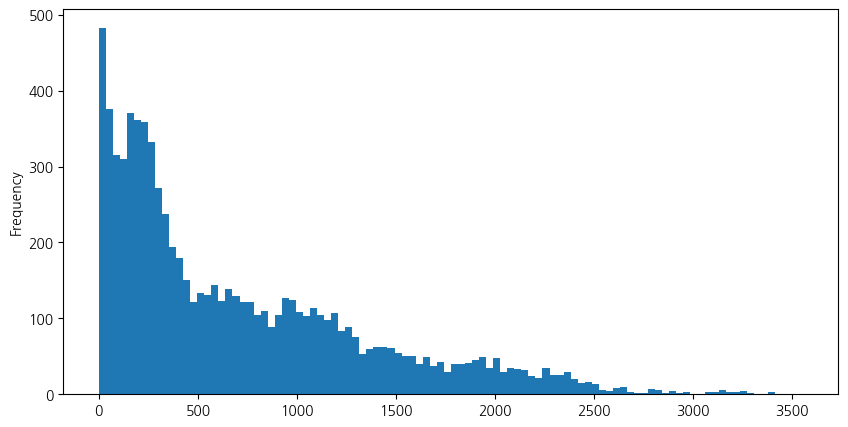

In [10]:
data_train['Rented Bike Count'].plot(kind='hist',bins=100,figsize=(10,5))

Rented Bike Count 변수는 Right-Skewed 분포를 띔.

### Hour 변수

In [11]:
data_train['Hour'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [12]:
data_train['Hour'].value_counts()

Hour
0     335
1     335
2     335
3     335
4     335
5     335
6     335
7     335
8     335
9     335
10    335
11    335
12    335
13    335
14    335
15    335
16    335
17    335
18    335
19    335
20    335
21    335
22    335
23    335
Name: count, dtype: int64

0시~23시의 데이터가 모두 335개로 동일한 것으로 보아, 해당 데이터는 335일 치의 데이터를 누적한 것이라고 판단 가능.


또한 행, 즉 시간대 자체가 완전 누락된 데이터는 없다고 판단 가능.

<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

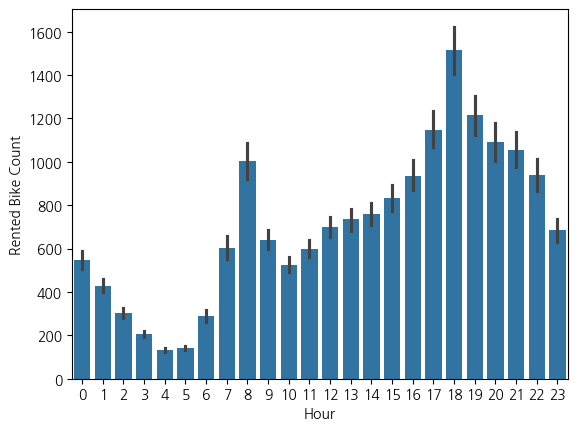

In [13]:
sns.barplot(data=data_train,x='Hour',y='Rented Bike Count')

8시와 18시가 가장 많은 것으로 보아 사람들이 출퇴근 수단으로 따릉이를 많이 이용했을 것이라고 예측 가능.. 

한데 과연 그럴까?

18시 저녁시간에 그냥 날이 좋아서 따릉이를 이용하는 사람도 많지 않을까?

결국 평일/주말 or 평일/공휴일로 나누어 출퇴근에 따릉이를 이용하는 사람이 많은지 봐야 할 것이다. (뒤 Holiday 변수에서!)

### Humidity(%) 변수

In [14]:
data_train['Humidity(%)'].value_counts()

Humidity(%)
97    166
53    155
57    149
51    148
56    148
     ... 
19     10
13      2
10      1
12      1
11      1
Name: count, Length: 90, dtype: int64

In [15]:
data_train['Humidity(%)'].describe()

count    8040.000000
mean       58.271020
std        20.340492
min         0.000000
25%        43.000000
50%        57.000000
75%        74.000000
max        98.000000
Name: Humidity(%), dtype: float64

<Axes: xlabel='Humidity(%)'>

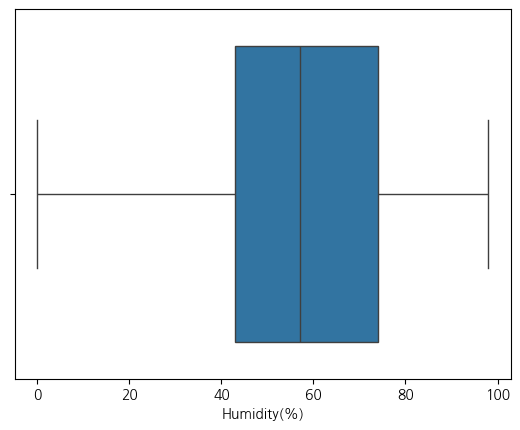

In [16]:
sns.boxplot(data=data_train,x='Humidity(%)')

<Axes: xlabel='Humidity(%)', ylabel='Rented Bike Count'>

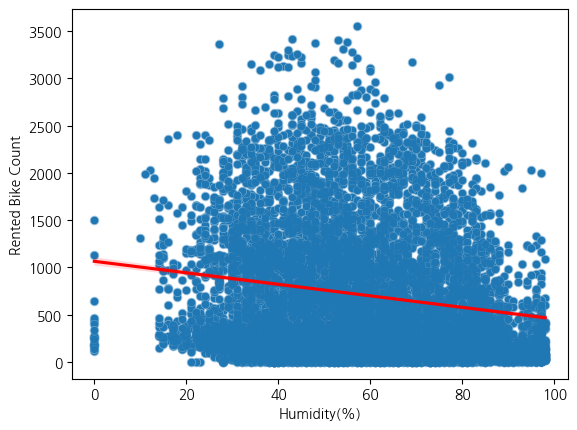

In [17]:
sns.scatterplot(data=data_train,x='Humidity(%)',y='Rented Bike Count')
sns.regplot(data=data_train,x='Humidity(%)',y='Rented Bike Count',line_kws={'color':'red'}, scatter_kws={'alpha':0.3})

습도가 높을수록 따릉이 대여량은 감소하였다고 판단.

<Axes: xlabel='Seasons', ylabel='Humidity(%)'>

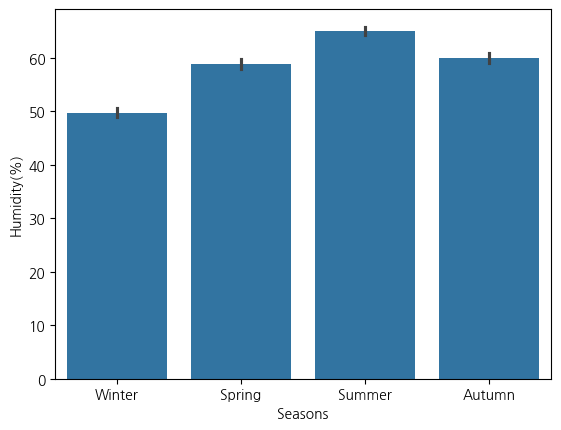

In [18]:
sns.barplot(data=data_train, x='Seasons', y='Humidity(%)')

In [19]:
# Humidity(%) 와 Rented Bike Count 간의 상관관계
correlation = data_train['Humidity(%)'].corr(data_train['Rented Bike Count'])
print(f"상관관계: {correlation}")

상관관계: -0.18857821321327467


딱히 큰 연관관계는 없다.

### Visibility (10m) 변수

In [20]:
data_train['Visibility (10m)'].describe()

count    8040.000000
mean     1459.170896
std       603.716284
min        27.000000
25%       977.000000
50%      1741.000000
75%      2000.000000
max      2000.000000
Name: Visibility (10m), dtype: float64

<Axes: xlabel='Visibility (10m)', ylabel='Rented Bike Count'>

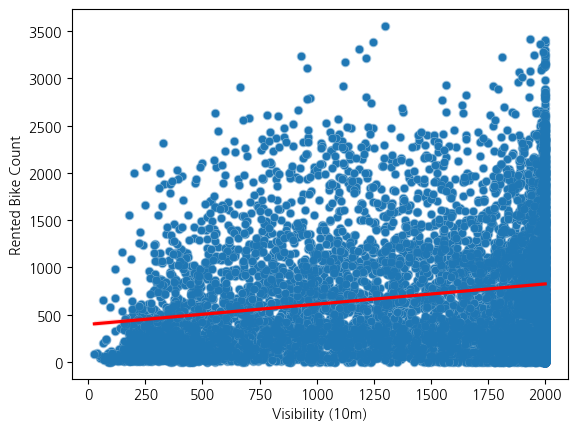

In [21]:
sns.scatterplot(data=data_train,x='Visibility (10m)',y='Rented Bike Count')
sns.regplot(data=data_train,x='Visibility (10m)',y='Rented Bike Count',line_kws={'color':'red'}, scatter_kws={'alpha':0.3})

In [22]:
# Visibility (10m) 와 Rented Bike Count 간의 상관관계
correlation = data_train['Visibility (10m)'].corr(data_train['Rented Bike Count'])
print(f"상관관계: {correlation}")

상관관계: 0.19671750239683383


마찬가지로 딱히 큰 연관관계가 있어보이진 않는다.

### Dew point temperature(C) 변수

: 이슬점 온도

In [23]:
data_train['Dew point temperature(C)'].describe()

count    8040.000000
mean        4.522239
std        13.393517
min       -30.600000
25%        -4.600000
50%         6.400000
75%        15.600000
max        27.200000
Name: Dew point temperature(C), dtype: float64

<Axes: xlabel='Dew point temperature(C)', ylabel='Rented Bike Count'>

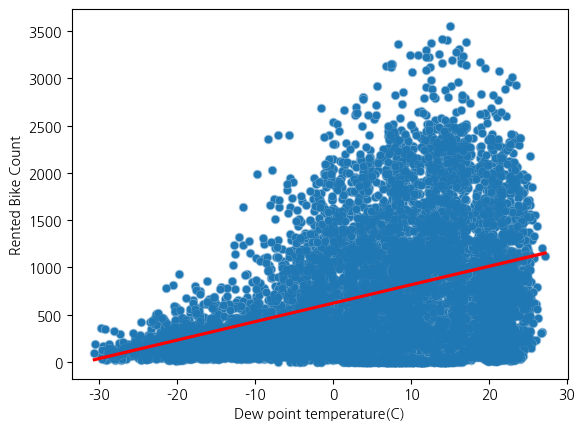

In [24]:
sns.scatterplot(data=data_train,x='Dew point temperature(C)',y='Rented Bike Count')
sns.regplot(data=data_train,x='Dew point temperature(C)',y='Rented Bike Count',line_kws={'color':'red'}, scatter_kws={'alpha':0.3})

In [25]:
# Dew point temperature(C) 와 Rented Bike Count 간의 상관관계
correlation = data_train['Dew point temperature(C)'].corr(data_train['Rented Bike Count'])
print(f"상관관계: {correlation}")

상관관계: 0.3980340206696657


In [26]:
# Dew point temperature(C) 와 Temperature(C) 간의 상관관계
correlation = data_train['Dew point temperature(C)'].corr(data_train['Temperature(C)'])
print(f"상관관계: {correlation}")

상관관계: 0.9170069117711002



![설명](이슬점공식.png)

- Dewpoint = 이슬점
- T = 기온
- RH = humidity

### Solar Radiation (MJ/m2) 변수

: 태양 복사 에너지

In [27]:
data_train['Solar Radiation (MJ/m2)'].describe()

count    8040.000000
mean        0.587072
std         0.886186
min         0.000000
25%         0.000000
50%         0.020000
75%         0.960000
max         3.520000
Name: Solar Radiation (MJ/m2), dtype: float64

<Axes: xlabel='Solar Radiation (MJ/m2)', ylabel='Rented Bike Count'>

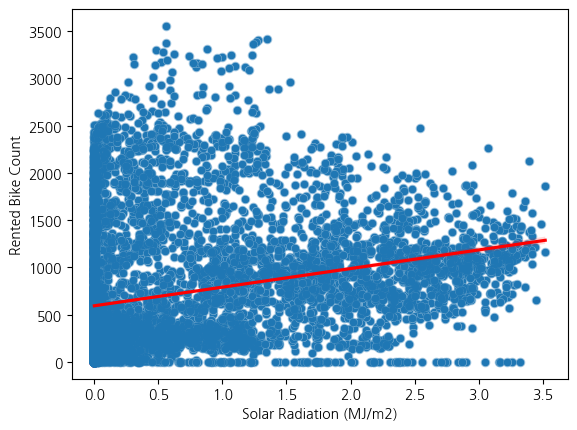

In [28]:
sns.scatterplot(data=data_train,x='Solar Radiation (MJ/m2)',y='Rented Bike Count')
sns.regplot(data=data_train,x='Solar Radiation (MJ/m2)',y='Rented Bike Count',line_kws={'color':'red'}, scatter_kws={'alpha':0.3})

<Axes: xlabel='Seasons', ylabel='Solar Radiation (MJ/m2)'>

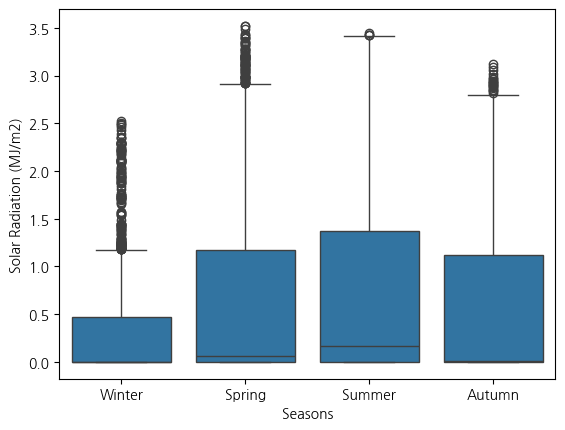

In [29]:
sns.boxplot(data=data_train,x='Seasons',y='Solar Radiation (MJ/m2)')

### Rainfall(mm), Snowfall(cm) 변수

: 강우량, 강설량

In [30]:
data_train['Rainfall(mm)'].describe()

count    8040.000000
mean        0.152164
std         1.127026
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        35.000000
Name: Rainfall(mm), dtype: float64

<Axes: xlabel='Seasons', ylabel='Rainfall(mm)'>

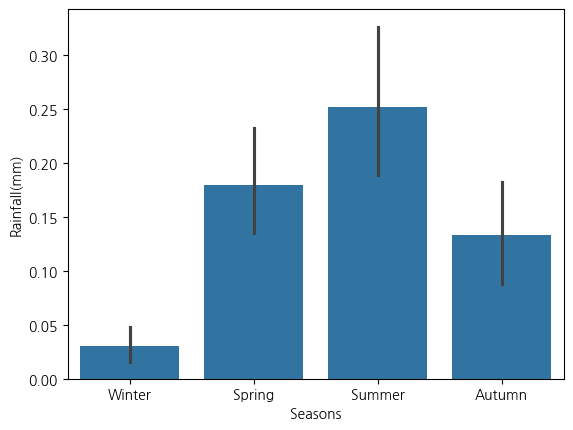

In [31]:
sns.barplot(data=data_train, x='Seasons', y='Rainfall(mm)')

In [32]:
# Rainfall(mm) 와 Rented Bike Count 간의 상관관계
correlation = data_train['Rainfall(mm)'].corr(data_train['Rented Bike Count'])
print(f"상관관계: {correlation}")

상관관계: -0.12392002841856536


In [33]:
data_train['Snowfall (cm)'].describe()

count    8040.000000
mean        0.066493
std         0.378182
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         5.100000
Name: Snowfall (cm), dtype: float64

<Axes: xlabel='Seasons', ylabel='Snowfall (cm)'>

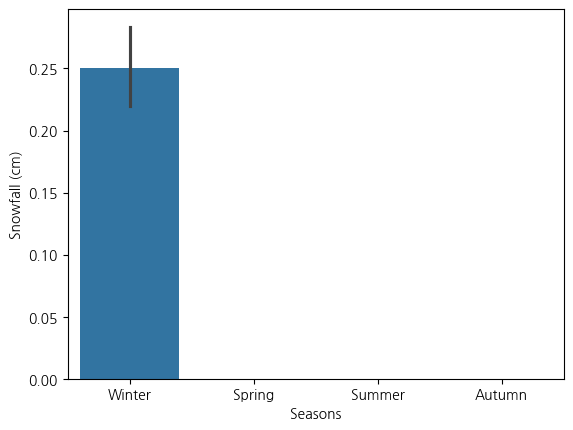

In [34]:
sns.barplot(data=data_train, x='Seasons', y='Snowfall (cm)')

In [35]:
# Snowfall (cm) 와 Rented Bike Count 간의 상관관계
correlation = data_train['Snowfall (cm)'].corr(data_train['Rented Bike Count'])
print(f"상관관계: {correlation}")

상관관계: -0.15062136776028723


굳이 강우량과 강설량, 그러니까 눈과 비로 나누어서 분석해야 할까..? 라는 의문이 듦.

그래서 강수량(=강우량+강설량)이란 변수를 만들기로 하였다.

강우량은 단위가 mm, 강설량은 단위가 cm으로 단위 통일이 필요하나 기상학에서는 적설비율 10:1, 즉 눈 1cm가 녹으면 물 10mm가 아닌 1mm로 환산한다고 하여 단위 통일에 대한 걱정은 pass

In [36]:
data_train['Precipitation(mm)'] = data_train['Rainfall(mm)'] + data_train['Snowfall (cm)']

In [37]:
data_train['Precipitation(mm)'].describe()

count    8040.000000
mean        0.218657
std         1.186261
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        35.000000
Name: Precipitation(mm), dtype: float64

<Axes: xlabel='Precipitation(mm)', ylabel='Rented Bike Count'>

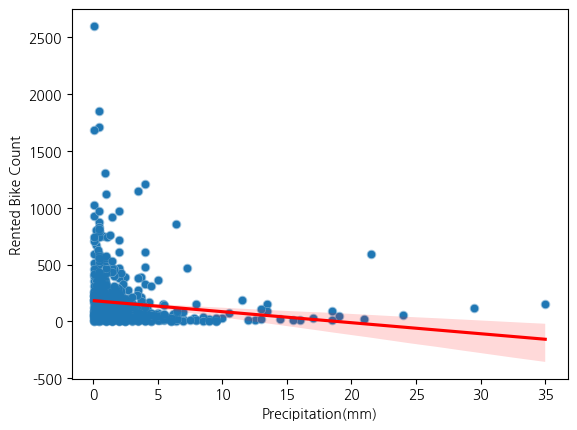

In [38]:
sns.scatterplot(data=data_train[data_train['Precipitation(mm)'] > 0.0],x='Precipitation(mm)',y='Rented Bike Count')
sns.regplot(data=data_train[data_train['Precipitation(mm)'] > 0.0],x='Precipitation(mm)',y='Rented Bike Count',line_kws={'color':'red'}, scatter_kws={'alpha':0.3})


In [39]:
# Precipitation(mm) 와 Rented Bike Count 간의 상관관계
correlation = data_train['Precipitation(mm)'].corr(data_train['Rented Bike Count'])
print(f"상관관계: {correlation}")

상관관계: -0.1657506051103376


### Seasons 변수

In [40]:
data_train['Seasons'].value_counts()

Seasons
Spring    1990
Summer    1990
Winter    1935
Autumn    1323
Name: count, dtype: int64

#### Seasons 변수 결측치 처리

In [41]:
data_train['Date'] = pd.to_datetime(data_train['Date'], format='%d/%m/%Y')
data_train['Year'] = data_train['Date'].dt.year
data_train['Month'] = data_train['Date'].dt.month
data_train['Day'] = data_train['Date'].dt.day

In [42]:
def Season(month):
    if month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    elif month in [9,10,11]:
        return 'Autumn'
    else:
        return 'Winter'

data_train['Seasons'] = data_train['Month'].apply(Season)

In [43]:
data_train['Seasons'].isna().sum()

np.int64(0)

In [44]:
data_train['Seasons'].value_counts().sum()

np.int64(8040)

<Axes: xlabel='Seasons', ylabel='Rented Bike Count'>

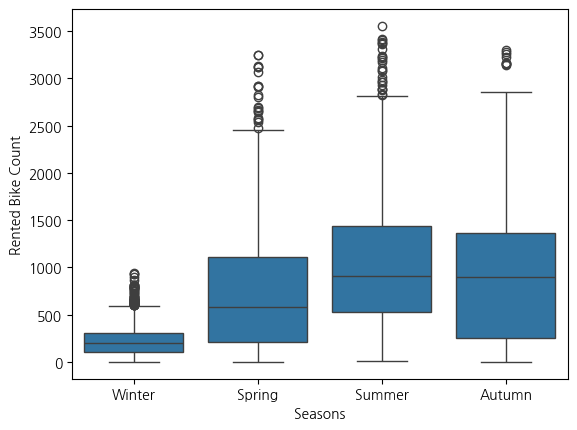

In [45]:
sns.boxplot(data=data_train,x='Seasons',y='Rented Bike Count')

여름에 가장 따릉이 대여량이 많았음.

주목할 만한 점은 봄보다 가을의 따릉이 대여량이 더 많음. 아마 train 데이터셋에서 날씨가 추워지는 11월 데이터가 빠져있어 봄보다 가을이 더 대여량이 높다고 나온듯 함.

달마다 분석하기 위해 Month 파생변수를 생성.

### Holiday 변수

In [46]:
data_train['Holiday'].value_counts()

Holiday
No Holiday    7608
Holiday        432
Name: count, dtype: int64

In [47]:
data_train[data_train['Holiday'] == 'Holiday']['Date'].unique()

<DatetimeArray>
['2017-12-22 00:00:00', '2017-12-24 00:00:00', '2017-12-25 00:00:00',
 '2017-12-31 00:00:00', '2018-01-01 00:00:00', '2018-02-15 00:00:00',
 '2018-02-16 00:00:00', '2018-02-17 00:00:00', '2018-03-01 00:00:00',
 '2018-05-01 00:00:00', '2018-05-22 00:00:00', '2018-06-06 00:00:00',
 '2018-08-15 00:00:00', '2018-09-23 00:00:00', '2018-09-24 00:00:00',
 '2018-09-25 00:00:00', '2018-10-03 00:00:00', '2018-10-09 00:00:00']
Length: 18, dtype: datetime64[us]

<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

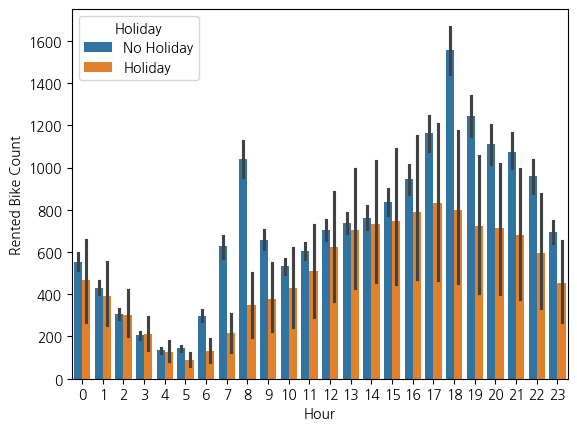

In [48]:
sns.barplot(data=data_train,x='Hour',y='Rented Bike Count',hue='Holiday')

Holiday : 법적으로 지정된 공휴일 / 휴일 (주말 아님!!)

따라서 Holiday 변수를 통해 따릉이가 과연 출퇴근에 유용하게 쓰이는지 알아볼 수 있을 것이다.

출퇴근 시간인 7~9시, 17~20시 시간대에서 유의미하게 No Holiday 값이 튀는 것을 발견.

많은 시민들이 No Holiday, 즉 평일(주말도 껴있지만..)에 따릉이로 출퇴근을 이용한다는 것을 유추 가능.

### Functioning Day 변수

In [49]:
data_train['Functioning Day'].value_counts()

Functioning Day
Yes    7817
No      223
Name: count, dtype: int64

In [50]:
data_train[data_train['Functioning Day'] == 'No']['Rented Bike Count'].unique()

array([0])

In [51]:
data_train[data_train['Functioning Day'] == 'No']['Date'].unique()

<DatetimeArray>
['2018-04-11 00:00:00', '2018-05-10 00:00:00', '2018-09-18 00:00:00',
 '2018-09-19 00:00:00', '2018-09-28 00:00:00', '2018-09-30 00:00:00',
 '2018-10-02 00:00:00', '2018-10-04 00:00:00', '2018-10-06 00:00:00',
 '2018-10-09 00:00:00']
Length: 10, dtype: datetime64[us]

Functioning Day는 따릉이 서비스 안하는 날을 의미.

# 기상청 데이터를 이용해 결측치 채우기
 * https://data.kma.go.kr/data/grnd/selectAsosRltmList.do?pgmNo=36
 * https://www.weather.go.kr/w/resources/pdf/kma_data_portal_guide.pdf
 * 일단 이 데이터로 결측치를 채우기 적절한지 판단하기 위해 2가지 정도 생각해볼 수 있다.
   1. 결측치를 제외한 나머지 값들이 모두 동일한가?
   
   2. 결측치 부분에 적절한 값이 들어가 있는가?
   

### Temperature(C) 변수

In [52]:
data_train['Temperature(C)'].describe()

count    7240.000000
mean       13.498564
std        12.270471
min       -17.800000
25%         3.500000
50%        15.600000
75%        23.300000
max        39.400000
Name: Temperature(C), dtype: float64

In [53]:
data_train['Temperature(C)'].isna().sum()

np.int64(800)

### Wind speed (m/s) 변수

In [54]:
data_train['Wind speed (m/s)'].describe()

count    7238.000000
mean        1.756756
std         1.045901
min         0.000000
25%         1.000000
50%         1.600000
75%         2.400000
max         7.400000
Name: Wind speed (m/s), dtype: float64

In [55]:
data_train['Wind speed (m/s)'].isna().sum()

np.int64(802)

### Temperature , Wind speed (m/s) 변수 결측치 채우기

In [56]:
data_train[data_train['Temperature(C)'] == 0]

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Precipitation(mm),Year,Month,Day
19,2017-12-01,600,19,0.0,77,1.7,2000,-3.5,0.00,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1
85,2017-12-04,391,13,0.0,30,NaN,1938,-15.5,1.17,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,4
203,2017-12-09,351,11,0.0,45,1.1,1500,-10.5,0.89,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,9
237,2017-12-10,167,21,0.0,59,3.0,1862,-7.0,0.00,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,10
352,2017-12-15,354,16,0.0,37,0.6,994,-12.9,0.13,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,15
426,2017-12-18,281,18,0.0,88,0.6,277,-1.7,0.00,0.0,2.7,Winter,No Holiday,Yes,2.7,2017,12,18
575,2017-12-24,128,23,0.0,63,3.2,884,-6.2,0.00,0.0,0.0,Winter,Holiday,Yes,0.0,2017,12,24
670,2017-12-28,285,22,0.0,63,1.3,968,-6.2,0.00,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,28
739,2017-12-31,163,19,0.0,31,2.2,2000,-15.1,0.00,0.0,0.0,Winter,Holiday,Yes,0.0,2017,12,31
1177,2018-01-19,207,1,0.0,43,1.7,1250,-11.1,0.00,0.0,0.0,Winter,No Holiday,Yes,0.0,2018,1,19


0은 결측치가 아니라 관측치임...

In [57]:
data_train[data_train['Temperature(C)'].isnull()]

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Precipitation(mm),Year,Month,Day
6,2017-12-01,181,6,NaN,35,1.3,2000,-19.5,0.00,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1
8,2017-12-01,930,8,NaN,37,1.1,2000,-19.8,0.01,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1
21,2017-12-01,405,21,NaN,81,0.8,1687,-3.6,0.00,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1
22,2017-12-01,398,22,NaN,83,1.5,1380,-3.4,0.00,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1
23,2017-12-01,323,23,NaN,84,NaN,1265,-3.6,0.00,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8021,2018-10-31,141,5,NaN,74,NaN,2000,-0.1,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31
8025,2018-10-31,996,9,NaN,56,1.8,1825,-2.9,0.89,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31
8027,2018-10-31,818,11,NaN,41,2.6,1907,-3.8,1.96,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31
8031,2018-10-31,994,15,NaN,35,NaN,1908,-3.0,1.72,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31


In [58]:
data_train[data_train['Temperature(C)'].isnull()]['Date'].unique()

<DatetimeArray>
['2017-12-01 00:00:00', '2017-12-02 00:00:00', '2017-12-03 00:00:00',
 '2017-12-04 00:00:00', '2017-12-05 00:00:00', '2017-12-06 00:00:00',
 '2017-12-07 00:00:00', '2017-12-08 00:00:00', '2017-12-09 00:00:00',
 '2017-12-10 00:00:00',
 ...
 '2018-10-22 00:00:00', '2018-10-23 00:00:00', '2018-10-24 00:00:00',
 '2018-10-25 00:00:00', '2018-10-26 00:00:00', '2018-10-27 00:00:00',
 '2018-10-28 00:00:00', '2018-10-29 00:00:00', '2018-10-30 00:00:00',
 '2018-10-31 00:00:00']
Length: 314, dtype: datetime64[us]

In [59]:
data_train[data_train['Wind speed (m/s)'].isnull()]

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Precipitation(mm),Year,Month,Day
4,2017-12-01,78,4,-6.0,36,NaN,2000,-18.6,0.00,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1
16,2017-12-01,484,16,1.2,54,NaN,793,-7.0,0.24,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1
23,2017-12-01,323,23,NaN,84,NaN,1265,-3.6,0.00,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1
43,2017-12-02,385,19,5.0,52,NaN,1666,-4.0,0.00,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,2
49,2017-12-03,227,1,3.9,69,NaN,485,-1.2,0.00,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8021,2018-10-31,141,5,NaN,74,NaN,2000,-0.1,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31
8031,2018-10-31,994,15,NaN,35,NaN,1908,-3.0,1.72,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31
8032,2018-10-31,1185,16,11.8,34,NaN,1979,-3.5,1.16,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31
8034,2018-10-31,2094,18,NaN,48,NaN,2000,-1.0,0.03,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31


In [60]:
data_train['Date'].head

<bound method NDFrame.head of 0      2017-12-01
1      2017-12-01
2      2017-12-01
3      2017-12-01
4      2017-12-01
          ...    
8035   2018-10-31
8036   2018-10-31
8037   2018-10-31
8038   2018-10-31
8039   2018-10-31
Name: Date, Length: 8040, dtype: datetime64[us]>

기상청 데이터(위 URL)에서 2017-12-01 ~ 2018-10-31 일자의 시간 단위 기온/풍속 데이터 다운!

In [61]:
missing_fill = pd.read_csv("OBS_ASOS_TIM_20260730022228.csv", encoding='cp949')

In [62]:
missing_fill.head()

,지점,지점명,일시,기온(°C),풍속(m/s)
0,108,서울,2017-12-01 01:00,-5.5,0.8
1,108,서울,2017-12-01 02:00,-6.0,1.0
2,108,서울,2017-12-01 03:00,-6.2,0.9
3,108,서울,2017-12-01 04:00,-6.0,2.3
4,108,서울,2017-12-01 05:00,-6.4,1.5


In [63]:
missing_fill['Hour'] = missing_fill['일시'].str[11:13].astype(int)

In [64]:
missing_fill.head()

,지점,지점명,일시,기온(°C),풍속(m/s),Hour
0,108,서울,2017-12-01 01:00,-5.5,0.8,1
1,108,서울,2017-12-01 02:00,-6.0,1.0,2
2,108,서울,2017-12-01 03:00,-6.2,0.9,3
3,108,서울,2017-12-01 04:00,-6.0,2.3,4
4,108,서울,2017-12-01 05:00,-6.4,1.5,5


In [65]:
missing_fill['일시'] = pd.to_datetime(missing_fill['일시'])

In [66]:
missing_fill.head()

,지점,지점명,일시,기온(°C),풍속(m/s),Hour
0,108,서울,2017-12-01 01:00:00,-5.5,0.8,1
1,108,서울,2017-12-01 02:00:00,-6.0,1.0,2
2,108,서울,2017-12-01 03:00:00,-6.2,0.9,3
3,108,서울,2017-12-01 04:00:00,-6.0,2.3,4
4,108,서울,2017-12-01 05:00:00,-6.4,1.5,5


In [67]:
data_train['Daytime'] = data_train['Date'] + pd.to_timedelta(data_train['Hour'], unit='h')

In [68]:
data_train['Daytime']

0      2017-12-01 00:00:00
1      2017-12-01 01:00:00
2      2017-12-01 02:00:00
3      2017-12-01 03:00:00
4      2017-12-01 04:00:00
               ...        
8035   2018-10-31 19:00:00
8036   2018-10-31 20:00:00
8037   2018-10-31 21:00:00
8038   2018-10-31 22:00:00
8039   2018-10-31 23:00:00
Name: Daytime, Length: 8040, dtype: datetime64[us]

In [69]:
missing_fill.drop(['지점','지점명'], axis=1, inplace=True)

In [70]:
missing_fill.rename(columns={'일시':'Daytime'}, inplace=True)

In [71]:
missing_fill.head()

,Daytime,기온(°C),풍속(m/s),Hour
0,2017-12-01 01:00:00,-5.5,0.8,1
1,2017-12-01 02:00:00,-6.0,1.0,2
2,2017-12-01 03:00:00,-6.2,0.9,3
3,2017-12-01 04:00:00,-6.0,2.3,4
4,2017-12-01 05:00:00,-6.4,1.5,5


In [72]:
# 기존 데이터에 daytime 기준으로 결측치를 채우는 merge 함수
merged = data_train.merge(missing_fill, how='left', on='Daytime')

In [73]:
merged.head()

,Date,Rented Bike Count,Hour_x,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),...,Holiday,Functioning Day,Precipitation(mm),Year,Month,Day,Daytime,기온(°C),풍속(m/s),Hour_y
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,No Holiday,Yes,0.0,2017,12,1,2017-12-01 00:00:00,NaN,NaN,NaN
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,No Holiday,Yes,0.0,2017,12,1,2017-12-01 01:00:00,-5.5,0.8,1.0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,No Holiday,Yes,0.0,2017,12,1,2017-12-01 02:00:00,-6.0,1.0,2.0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,No Holiday,Yes,0.0,2017,12,1,2017-12-01 03:00:00,-6.2,0.9,3.0
4,2017-12-01,78,4,-6.0,36,NaN,2000,-18.6,0.0,0.0,...,No Holiday,Yes,0.0,2017,12,1,2017-12-01 04:00:00,-6.0,2.3,4.0


In [74]:
data_train['Temperature(C)'] = data_train['Temperature(C)'].fillna(merged['기온(°C)'])
data_train['Wind speed (m/s)'] = data_train['Wind speed (m/s)'].fillna(merged['풍속(m/s)'])

In [75]:
data_train.isna().sum()

Date                        0
Rented Bike Count           0
Hour                        0
Temperature(C)              5
Humidity(%)                 0
Wind speed (m/s)            8
Visibility (10m)            0
Dew point temperature(C)    0
Solar Radiation (MJ/m2)     0
Rainfall(mm)                0
Snowfall (cm)               0
Seasons                     0
Holiday                     0
Functioning Day             0
Precipitation(mm)           0
Year                        0
Month                       0
Day                         0
Daytime                     0
dtype: int64

In [76]:
data_train[data_train['Temperature(C)'].isna()]

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Precipitation(mm),Year,Month,Day,Daytime
8021,2018-10-31,141,5,NaN,74,NaN,2000,-0.1,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 05:00:00
8025,2018-10-31,996,9,NaN,56,1.8,1825,-2.9,0.89,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 09:00:00
8027,2018-10-31,818,11,NaN,41,2.6,1907,-3.8,1.96,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 11:00:00
8031,2018-10-31,994,15,NaN,35,NaN,1908,-3.0,1.72,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 15:00:00
8034,2018-10-31,2094,18,NaN,48,NaN,2000,-1.0,0.03,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 18:00:00


In [77]:
data_train[data_train['Date'] == '2018-10-31']

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Precipitation(mm),Year,Month,Day,Daytime
8016,2018-10-31,294,0,7.1,59,1.7,2000,-0.3,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 00:00:00
8017,2018-10-31,324,1,6.6,66,1.0,2000,0.6,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 01:00:00
8018,2018-10-31,287,2,6.4,65,0.0,2000,0.2,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 02:00:00
8019,2018-10-31,227,3,5.6,69,0.1,2000,0.3,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 03:00:00
8020,2018-10-31,146,4,5.0,71,NaN,1994,0.1,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 04:00:00
8021,2018-10-31,141,5,NaN,74,NaN,2000,-0.1,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 05:00:00
8022,2018-10-31,402,6,3.6,75,0.8,2000,-0.4,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 06:00:00
8023,2018-10-31,1060,7,3.2,74,0.9,2000,-0.9,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 07:00:00
8024,2018-10-31,1907,8,3.7,67,1.8,1987,-1.8,0.15,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 08:00:00
8025,2018-10-31,996,9,NaN,56,1.8,1825,-2.9,0.89,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 09:00:00


In [78]:
# 누락된 결측치를 그 앞 뒷 데이터의 평균값으로 대체.
data_train['Temperature(C)'] = data_train['Temperature(C)'].interpolate(method='linear')
data_train['Wind speed (m/s)'] = data_train['Wind speed (m/s)'].interpolate(method='linear')

In [79]:
data_train[data_train['Date'] == '2018-10-31']

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Precipitation(mm),Year,Month,Day,Daytime
8016,2018-10-31,294,0,7.10,59,1.700000,2000,-0.3,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 00:00:00
8017,2018-10-31,324,1,6.60,66,1.000000,2000,0.6,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 01:00:00
8018,2018-10-31,287,2,6.40,65,0.000000,2000,0.2,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 02:00:00
8019,2018-10-31,227,3,5.60,69,0.100000,2000,0.3,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 03:00:00
8020,2018-10-31,146,4,5.00,71,0.333333,1994,0.1,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 04:00:00
8021,2018-10-31,141,5,4.30,74,0.566667,2000,-0.1,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 05:00:00
8022,2018-10-31,402,6,3.60,75,0.800000,2000,-0.4,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 06:00:00
8023,2018-10-31,1060,7,3.20,74,0.900000,2000,-0.9,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 07:00:00
8024,2018-10-31,1907,8,3.70,67,1.800000,1987,-1.8,0.15,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 08:00:00
8025,2018-10-31,996,9,5.45,56,1.800000,1825,-2.9,0.89,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018,10,31,2018-10-31 09:00:00


In [80]:
data_train.isna().sum()

Date                        0
Rented Bike Count           0
Hour                        0
Temperature(C)              0
Humidity(%)                 0
Wind speed (m/s)            0
Visibility (10m)            0
Dew point temperature(C)    0
Solar Radiation (MJ/m2)     0
Rainfall(mm)                0
Snowfall (cm)               0
Seasons                     0
Holiday                     0
Functioning Day             0
Precipitation(mm)           0
Year                        0
Month                       0
Day                         0
Daytime                     0
dtype: int64

### Temperature(C) 변수

In [81]:
data_train['Temperature(C)'].describe()

count    8040.000000
mean       13.337394
std        12.291961
min       -17.800000
25%         3.200000
50%        15.350000
75%        23.200000
max        39.400000
Name: Temperature(C), dtype: float64

<Axes: xlabel='Seasons', ylabel='Temperature(C)'>

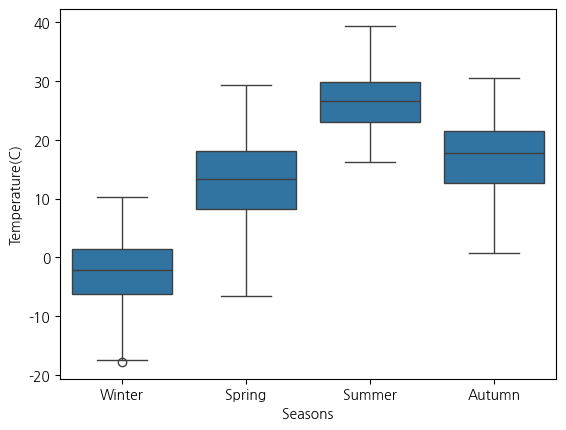

In [82]:
sns.boxplot(data=data_train,x='Seasons', y='Temperature(C)')

<Axes: xlabel='Month', ylabel='Temperature(C)'>

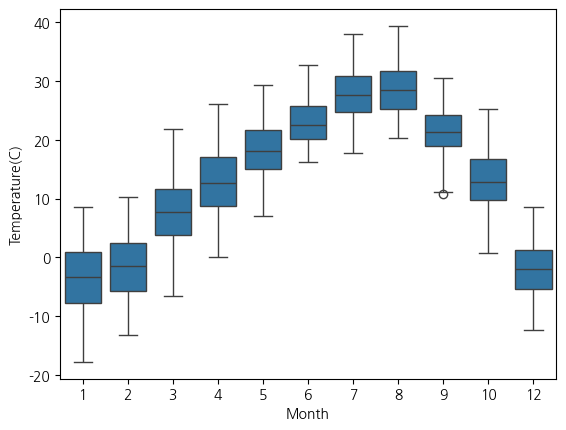

In [83]:
sns.boxplot(data=data_train,x='Month',y='Temperature(C)')

<Axes: xlabel='Temperature(C)', ylabel='Rented Bike Count'>

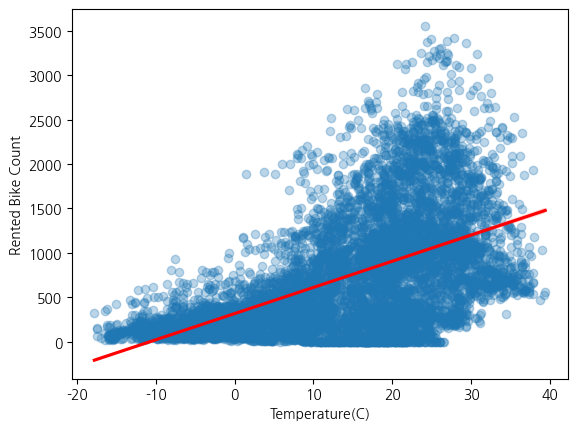

In [84]:
sns.regplot(data=data_train,x='Temperature(C)',y='Rented Bike Count',line_kws={'color':'red'}, scatter_kws={'alpha':0.3})

In [85]:
correlation = data_train['Temperature(C)'].corr(data_train['Rented Bike Count'])
print(f"상관관계: {correlation}")

상관관계: 0.5513934216466635


### Wind speed (m/s) 변수

In [86]:
data_train['Wind speed (m/s)'].describe()

count    8040.000000
mean        1.754963
std         1.046720
min         0.000000
25%         1.000000
50%         1.600000
75%         2.400000
max         7.400000
Name: Wind speed (m/s), dtype: float64

<Axes: xlabel='Wind speed (m/s)', ylabel='Rented Bike Count'>

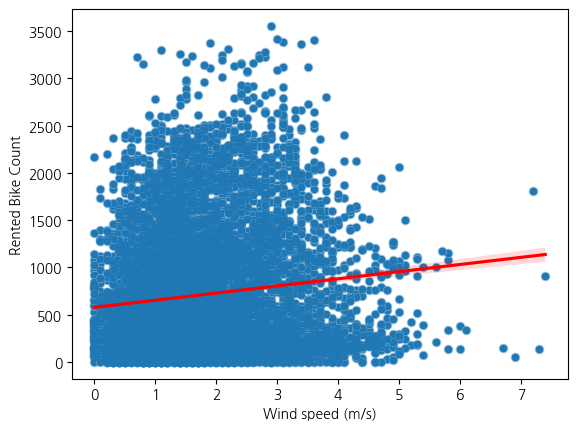

In [87]:
sns.scatterplot(data=data_train,x='Wind speed (m/s)',y='Rented Bike Count')
sns.regplot(data=data_train,x='Wind speed (m/s)',y='Rented Bike Count',line_kws={'color':'red'}, scatter_kws={'alpha':0.3})

풍속이 높을 수록 따릉이 대여량이 증가하였다고 판단.
마찬가지로 직선 기울기를 보아 영향을 적음.

<Axes: xlabel='Seasons', ylabel='Wind speed (m/s)'>

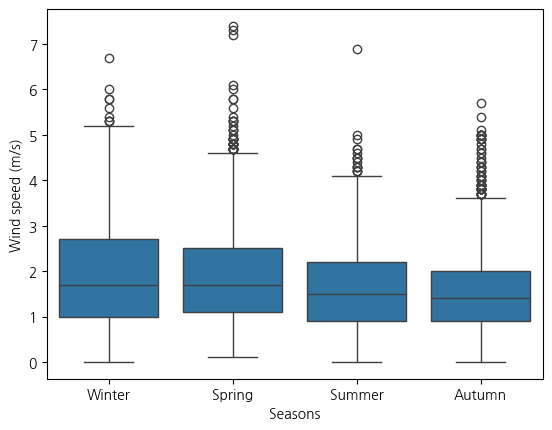

In [88]:
sns.boxplot(data=data_train,x='Seasons',y='Wind speed (m/s)')

Wind speed 변수는 딱히 계절과 관련 없는 변수라 판단.

# Test Data EDA

In [89]:
data_test = pd.read_csv("test.csv")

In [90]:
data_test.head()

,Date,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/11/2018,0,5.7,62,2.3,1909,-1.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
1,01/11/2018,1,5.1,65,1.6,1932,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
2,01/11/2018,2,4.4,64,NaN,2000,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
3,01/11/2018,3,4.2,65,0.7,1962,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
4,01/11/2018,4,3.6,70,0.8,1934,-1.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [91]:
data_test = data_test.rename(columns={'Temperature(째C)':'Temperature(C)','Dew point temperature(째C)':'Dew point temperature(C)'})

In [92]:
data_test.isna().sum()

Date                         0
Hour                         0
Temperature(C)              76
Humidity(%)                  0
Wind speed (m/s)            74
Visibility (10m)             0
Dew point temperature(C)     0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                     74
Holiday                      0
Functioning Day              0
dtype: int64

In [93]:
data_test['Date']

0      01/11/2018
1      01/11/2018
2      01/11/2018
3      01/11/2018
4      01/11/2018
          ...    
715    30/11/2018
716    30/11/2018
717    30/11/2018
718    30/11/2018
719    30/11/2018
Name: Date, Length: 720, dtype: str

In [94]:
# test 데이터는 11월 데이터이므로, Seasons 변수를 Autumn으로 설정
data_test['Seasons'] = 'Autumn'

In [95]:
data_test['Precipitation(mm)'] = data_test['Rainfall(mm)'] + data_test['Snowfall (cm)']

In [96]:
missing_test_fill = pd.read_csv("OBS_ASOS_TIM_20260730154955.csv", encoding='cp949')
missing_test_fill.head()

,지점,지점명,일시,기온(°C),풍속(m/s)
0,108,서울,2018-11-01 01:00,5.1,1.6
1,108,서울,2018-11-01 02:00,4.4,1.4
2,108,서울,2018-11-01 03:00,4.2,0.7
3,108,서울,2018-11-01 04:00,3.6,0.8
4,108,서울,2018-11-01 05:00,3.3,0.0


In [97]:
missing_test_fill.drop(['지점','지점명'], axis=1, inplace=True)

In [98]:
missing_test_fill['Hour'] = missing_test_fill['일시'].str[11:13].astype(int)
missing_test_fill['일시'] = pd.to_datetime(missing_test_fill['일시'])
data_test['Date'] = pd.to_datetime(data_test['Date'], format='%d/%m/%Y')
data_test['Hour'] = data_test['Hour'].astype(int)
data_test['Daytime'] = data_test['Date'] + pd.to_timedelta(data_test['Hour'], unit='h')

In [99]:
data_test.head()

,Date,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Precipitation(mm),Daytime
0,2018-11-01,0,5.7,62,2.3,1909,-1.0,0.0,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018-11-01 00:00:00
1,2018-11-01,1,5.1,65,1.6,1932,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018-11-01 01:00:00
2,2018-11-01,2,4.4,64,NaN,2000,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018-11-01 02:00:00
3,2018-11-01,3,4.2,65,0.7,1962,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018-11-01 03:00:00
4,2018-11-01,4,3.6,70,0.8,1934,-1.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018-11-01 04:00:00


In [100]:
missing_test_fill.rename(columns={'일시':'Daytime'}, inplace=True)

In [101]:
merged = data_test.merge(missing_test_fill, how='left', on='Daytime')

In [102]:
merged.head()

,Date,Hour_x,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Precipitation(mm),Daytime,기온(°C),풍속(m/s),Hour_y
0,2018-11-01,0,5.7,62,2.3,1909,-1.0,0.0,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018-11-01 00:00:00,NaN,NaN,NaN
1,2018-11-01,1,5.1,65,1.6,1932,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018-11-01 01:00:00,5.1,1.6,1.0
2,2018-11-01,2,4.4,64,NaN,2000,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018-11-01 02:00:00,4.4,1.4,2.0
3,2018-11-01,3,4.2,65,0.7,1962,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018-11-01 03:00:00,4.2,0.7,3.0
4,2018-11-01,4,3.6,70,0.8,1934,-1.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018-11-01 04:00:00,3.6,0.8,4.0


In [103]:
data_test['Temperature(C)'] = data_test['Temperature(C)'].fillna(merged['기온(°C)'])
data_test['Wind speed (m/s)'] = data_test['Wind speed (m/s)'].fillna(merged['풍속(m/s)'])

In [104]:
data_test.isna().sum()

Date                        0
Hour                        0
Temperature(C)              1
Humidity(%)                 0
Wind speed (m/s)            0
Visibility (10m)            0
Dew point temperature(C)    0
Solar Radiation (MJ/m2)     0
Rainfall(mm)                0
Snowfall (cm)               0
Seasons                     0
Holiday                     0
Functioning Day             0
Precipitation(mm)           0
Daytime                     0
dtype: int64

In [105]:
data_test[data_test['Temperature(C)'].isna()]

,Date,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Precipitation(mm),Daytime
690,2018-11-29,18,NaN,46,0.9,1566,-4.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,0.0,2018-11-29 18:00:00


In [106]:
data_test['Temperature(C)'] = data_test['Temperature(C)'].interpolate(method='linear')

In [107]:
data_test.isna().sum()

Date                        0
Hour                        0
Temperature(C)              0
Humidity(%)                 0
Wind speed (m/s)            0
Visibility (10m)            0
Dew point temperature(C)    0
Solar Radiation (MJ/m2)     0
Rainfall(mm)                0
Snowfall (cm)               0
Seasons                     0
Holiday                     0
Functioning Day             0
Precipitation(mm)           0
Daytime                     0
dtype: int64

# Modeling

In [108]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8040 entries, 0 to 8039
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      8040 non-null   datetime64[us]
 1   Rented Bike Count         8040 non-null   int64         
 2   Hour                      8040 non-null   int64         
 3   Temperature(C)            8040 non-null   float64       
 4   Humidity(%)               8040 non-null   int64         
 5   Wind speed (m/s)          8040 non-null   float64       
 6   Visibility (10m)          8040 non-null   int64         
 7   Dew point temperature(C)  8040 non-null   float64       
 8   Solar Radiation (MJ/m2)   8040 non-null   float64       
 9   Rainfall(mm)              8040 non-null   float64       
 10  Snowfall (cm)             8040 non-null   float64       
 11  Seasons                   8040 non-null   str           
 12  Holiday                   8040 

In [109]:
data_train.head()

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Precipitation(mm),Year,Month,Day,Daytime
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1,2017-12-01 00:00:00
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1,2017-12-01 01:00:00
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1,2017-12-01 02:00:00
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1,2017-12-01 03:00:00
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,0.0,2017,12,1,2017-12-01 04:00:00


In [110]:
from sklearn.model_selection import train_test_split

In [111]:
X = data_train[data_train.drop(columns=['Rainfall(mm)', 'Snowfall (cm)', 'Rented Bike Count', 'Year', 'Month', 'Day' , 'Date', 'Daytime']).columns]
y = data_train['Rented Bike Count']

In [112]:
X.head()

,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Seasons,Holiday,Functioning Day,Precipitation(mm)
0,0,-5.2,37,2.2,2000,-17.6,0.0,Winter,No Holiday,Yes,0.0
1,1,-5.5,38,0.8,2000,-17.6,0.0,Winter,No Holiday,Yes,0.0
2,2,-6.0,39,1.0,2000,-17.7,0.0,Winter,No Holiday,Yes,0.0
3,3,-6.2,40,0.9,2000,-17.6,0.0,Winter,No Holiday,Yes,0.0
4,4,-6.0,36,2.3,2000,-18.6,0.0,Winter,No Holiday,Yes,0.0


In [113]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
X_test = data_test[data_test.drop(columns=['Rainfall(mm)', 'Snowfall (cm)', 'Date', 'Daytime']).columns]

In [114]:
# One-hot encoding
X_train = pd.get_dummies(X_train, columns=['Seasons', 'Holiday', 'Functioning Day'], drop_first=True)
X_valid = pd.get_dummies(X_valid, columns=['Seasons', 'Holiday', 'Functioning Day'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Seasons', 'Holiday', 'Functioning Day'], drop_first=True)

### RandomForestRegressor

In [115]:
from sklearn.ensemble import RandomForestRegressor # 타겟 변수가 수치형이므로 Classifier가 아닌 Regressor를 사용!

In [116]:
model = RandomForestRegressor(random_state=42) # 랜덤포레스트 모델 생성
model

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [117]:
model.fit(X_train, y_train) # 학습 수행

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [118]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(model, X_train, y_train, X_valid, y_valid):
    y_train_pred = model.predict(X_train) # 학습 데이터에 대한 예측 수행
    y_valid_pred = model.predict(X_valid) # 검증 데이터에 대한 예측 수행
    
    print("Train")
    print("MSE:", mean_squared_error(y_train, y_train_pred))
    print("R2:", r2_score(y_train, y_train_pred))
    
    print("\nValidation")
    print("MSE:", mean_squared_error(y_valid, y_valid_pred))
    print("R2:", r2_score(y_valid, y_valid_pred))

evaluate_model(model, X_train, y_train, X_valid, y_valid)

Train
MSE: 7562.724696843906
R2: 0.9824258235418447

Validation
MSE: 50738.52595068408
R2: 0.8843426505079085


r2 score가 0.98으로 너무 높아 과적합 우려..

In [119]:
from sklearn.model_selection import GridSearchCV

hyperparameters = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_model = GridSearchCV(estimator=model, param_grid=hyperparameters, cv=5, scoring='r2', n_jobs=-1)
grid_model.fit(X_train, y_train)
best_model = grid_model.best_estimator_

In [120]:
print("Best Hyperparameters:", grid_model.best_params_)

Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [121]:
best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [122]:
evaluate_model(best_model, X_train, y_train, X_valid, y_valid)

Train
MSE: 7387.114279625311
R2: 0.9828339050976069

Validation
MSE: 50675.973214738806
R2: 0.8844852380882009


best hyperparameter를 찾아도 과적합 우려..

### GradientBoostingRegressor

In [123]:
from sklearn.ensemble import GradientBoostingRegressor

In [124]:
model = GradientBoostingRegressor(random_state=42)
model

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [125]:
model.fit(X_train, y_train) # 학습 수행

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [126]:
evaluate_model(model, X_train, y_train, X_valid, y_valid)

Train
MSE: 60903.92163408889
R2: 0.8584721368691608

Validation
MSE: 63096.21139896257
R2: 0.8561735794120304


In [127]:

hyperparameters = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_model = GridSearchCV(estimator=model, param_grid=hyperparameters, cv=5, scoring='r2', n_jobs=-1)
grid_model.fit(X_train, y_train)
best_model = grid_model.best_estimator_


In [128]:
print("Best Hyperparameters:", grid_model.best_params_)

Best Hyperparameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


In [129]:
best_model.fit(X_train, y_train)
evaluate_model(best_model, X_train, y_train, X_valid, y_valid)

Train
MSE: 25773.72507384953
R2: 0.9401073011925396

Validation
MSE: 51616.52209910313
R2: 0.8823412776755737


MSE가 튀긴 하지만 GradientBoostingRegressor 모델 채택.

In [133]:
X_train.head()

,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Precipitation(mm),Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes
921,9,0.8,47,0.9,1070,-9.2,0.05,0.0,False,False,True,True,True
322,10,-7.7,43,0.9,1555,-18.1,0.35,0.0,False,False,True,True,True
4299,3,20.0,58,1.8,1279,11.4,0.00,0.0,True,False,False,True,True
4907,11,27.5,31,1.9,1841,8.8,2.70,0.0,False,True,False,True,True
6217,1,23.4,47,2.1,2000,11.4,0.00,0.0,False,True,False,True,True


In [131]:
X_test.head()

,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Precipitation(mm),Functioning Day_Yes
0,0,5.7,62,2.3,1909,-1.0,0.0,0.0,True
1,1,5.1,65,1.6,1932,-0.9,0.0,0.0,True
2,2,4.4,64,1.4,2000,-1.8,0.0,0.0,True
3,3,4.2,65,0.7,1962,-1.8,0.0,0.0,True
4,4,3.6,70,0.8,1934,-1.3,0.0,0.0,True


In [137]:
X_test['Seasons_Spring'] = False
X_test['Seasons_Summer'] = False
X_test['Seasons_Winter'] = False
X_test['Holiday_No Holiday'] = True

X_test_reindexed = X_test.reindex(columns=X_train.columns, fill_value=0)

In [139]:
X_test_reindexed.head()

,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Precipitation(mm),Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes
0,0,5.7,62,2.3,1909,-1.0,0.0,0.0,False,False,False,True,True
1,1,5.1,65,1.6,1932,-0.9,0.0,0.0,False,False,False,True,True
2,2,4.4,64,1.4,2000,-1.8,0.0,0.0,False,False,False,True,True
3,3,4.2,65,0.7,1962,-1.8,0.0,0.0,False,False,False,True,True
4,4,3.6,70,0.8,1934,-1.3,0.0,0.0,False,False,False,True,True


In [150]:
best_model = GradientBoostingRegressor(max_depth=5, min_samples_split=5, n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test_reindexed).round().astype(int)

In [156]:
data_test['Rented Bike Count'] = pred
data_test.loc[data_test['Functioning Day'] == 'No', 'Rented Bike Count'] = 0
data_test[['Date', 'Rented Bike Count']].to_csv('Ddareungi.csv', index=False)